# MONTE CARLO PERMUTATION METHOD (MCP)

## Objectif du notebook

Ce notebook transforme le concept de **Monte Carlo Permutation Method**, ou **MCP**, en démonstration concrète de trading/backtest.

L'idée centrale :

> Une stratégie n'a pas seulement besoin de faire du profit. Elle doit faire un profit qui dépend du **bon appariement temporel** entre ses signaux et les rendements du marché.

Le MCP répond donc à une question très précise :

> Si je garde mes signaux tels quels, mais que je mélange les rendements du marché, est-ce que ma stratégie reste aussi bonne ?

Si oui, mauvaise nouvelle : la stratégie ressemble à une coïncidence chanceuse.  
Si non, bonne nouvelle potentielle : le lien signal/prix semble contenir une vraie information.

## 1. L'intuition simple

Imagine que ta stratégie donne une suite de décisions :

- `+1` : être long
- `-1` : être short
- `0` : ne rien faire

Et que le marché donne une suite de rendements quotidiens.

Dans le vrai backtest, tu fais :

```text
profit du jour = signal du jour × rendement du marché du jour
```

Le MCP fait une expérience de pensée :

```text
profit bruit = signal original du jour × rendement d'un autre jour tiré au hasard
```

On garde donc les mêmes signaux, mais on casse le lien logique entre le signal et le bon jour de marché.

C'est comme demander :

> Est-ce que mes signaux étaient vraiment placés aux bons endroits, ou est-ce qu'ils auraient gagné même si on les avait associés à des jours random ?

## 2. MCP vs Bootstrap : la différence qui compte

Le **Bootstrap classique** rééchantillonne souvent les rendements de la stratégie pour tester si la moyenne observée est rare sous une hypothèse nulle.

Le **MCP**, lui, cible autre chose :

| Méthode | Ce qu'elle teste principalement | Ce qu'elle casse |
|---|---|---|
| Bootstrap | La moyenne des rendements de la stratégie | L'échantillonnage des résultats |
| MCP | La relation temporelle entre signal et marché | Le lien signal → rendement |

Donc MCP est particulièrement utile quand tu veux valider une logique de signal.

Exemple EBTA :

> Mon setup n'est pas intéressant parce qu'il a gagné dans le passé. Il est intéressant seulement si le placement exact de ses signaux donne un résultat que le hasard ne reproduit pas.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_days = 800
n_permutations = 5000

print("Notebook prêt.")
print(f"Nombre de jours simulés : {n_days}")
print(f"Nombre de permutations MCP : {n_permutations}")

Notebook prêt.
Nombre de jours simulés : 800
Nombre de permutations MCP : 5000


## 3. Créons un mini-marché artificiel

On va créer une série de rendements journaliers.

Pour rendre l'exemple parlant, on va créer une stratégie qui possède un **petit edge réel** :

- quand le rendement du jour est positif, le signal est souvent `+1` ;
- quand le rendement du jour est négatif, le signal est souvent `-1` ;
- mais le signal reste imparfait, comme dans la vraie vie.

L'objectif n'est pas de construire une vraie stratégie, mais de rendre visible la logique statistique du MCP.

In [2]:
market_returns_raw = np.random.normal(loc=0.00025, scale=0.01, size=n_days)

# Detrending : on enlève le drift moyen du marché
market_returns_detrended = market_returns_raw - market_returns_raw.mean()

# Création de signaux avec un léger pouvoir prédictif artificiel
true_direction = np.sign(market_returns_detrended)
true_direction[true_direction == 0] = 1

accuracy = 0.56
random_flip = np.random.rand(n_days) > accuracy

signals = true_direction.copy()
signals[random_flip] *= -1

# Ajout de jours sans position
flat_days = np.random.rand(n_days) < 0.20
signals[flat_days] = 0

df = pd.DataFrame({
    "market_return_raw": market_returns_raw,
    "market_return_detrended": market_returns_detrended,
    "signal": signals,
})

df["strategy_return_real"] = df["signal"] * df["market_return_detrended"]

df.head(10)

,market_return_raw,market_return_detrended,signal,strategy_return_real
0,0.005217,0.005046,1.0,0.005046
1,-0.001133,-0.001304,1.0,-0.001304
2,0.006727,0.006556,1.0,0.006556
3,0.015480,0.015309,-1.0,-0.015309
4,-0.002092,-0.002263,-1.0,0.002263
5,-0.002091,-0.002262,-1.0,0.002262
6,0.016042,0.015871,1.0,0.015871
7,0.007924,0.007753,-1.0,-0.007753
8,-0.004445,-0.004616,0.0,-0.000000
9,0.005676,0.005505,-1.0,-0.005505


## 4. Performance réelle de la stratégie

On calcule maintenant le rendement moyen réel de la stratégie.

Ce chiffre seul ne prouve rien.

Pourquoi ?

Parce qu'un bon résultat de backtest peut venir de trois choses :

1. un vrai pouvoir prédictif ;
2. un simple drift haussier du marché ;
3. une coïncidence chanceuse entre signaux et rendements.

Le MCP cherche surtout à neutraliser le point 3.

In [3]:
real_mean_return = df["strategy_return_real"].mean()
real_total_return = df["strategy_return_real"].sum()
real_annualized_return = real_mean_return * 252

summary_real = pd.DataFrame({
    "Mesure": [
        "Rendement moyen quotidien réel",
        "Rendement annualisé approximatif",
        "Somme des rendements quotidiens",
        "Pourcentage de jours en position"
    ],
    "Valeur": [
        real_mean_return,
        real_annualized_return,
        real_total_return,
        (df["signal"] != 0).mean()
    ]
})

summary_real

,Mesure,Valeur
0,Rendement moyen quotidien réel,0.000365
1,Rendement annualisé approximatif,0.091912
2,Somme des rendements quotidiens,0.291785
3,Pourcentage de jours en position,0.807500


## 5. Le coeur du MCP : mélanger les rendements sans remise

Le MCP fait ceci :

1. garder la séquence originale des signaux ;
2. mélanger l'ordre des rendements de marché detrendés ;
3. multiplier les signaux originaux par ces rendements mélangés ;
4. calculer la moyenne ;
5. recommencer des milliers de fois.

Chaque permutation représente une **noise rule** :

> une version de la stratégie où les signaux existent, mais ne tombent plus sur les bons jours.

Important :

- le mélange est **sans remise** ;
- chaque rendement historique est utilisé une seule fois par permutation ;
- on conserve la distribution globale du marché ;
- mais on détruit le lien temporel signal/prix.

In [4]:
def monte_carlo_permutation_test(signals, returns, n_permutations=5000, seed=42):
    rng = np.random.default_rng(seed)

    signals = np.asarray(signals)
    returns = np.asarray(returns)

    real_strategy_returns = signals * returns
    real_mean = real_strategy_returns.mean()

    permuted_means = np.empty(n_permutations)

    for i in range(n_permutations):
        permuted_returns = rng.permutation(returns)  # sans remise
        noise_strategy_returns = signals * permuted_returns
        permuted_means[i] = noise_strategy_returns.mean()

    # Test unilatéral à droite :
    # combien de fois le hasard fait-il aussi bien ou mieux que la stratégie réelle ?
    p_value = np.mean(permuted_means >= real_mean)

    return real_mean, permuted_means, p_value


real_mean, permuted_means, p_value = monte_carlo_permutation_test(
    signals=df["signal"],
    returns=df["market_return_detrended"],
    n_permutations=n_permutations,
    seed=42
)

print(f"Rendement moyen réel : {real_mean:.8f}")
print(f"Moyenne des noise rules : {permuted_means.mean():.8f}")
print(f"p-value MCP : {p_value:.4f}")

Rendement moyen réel : 0.00036473
Moyenne des noise rules : -0.00000415
p-value MCP : 0.1206


## 6. Visualisation : la stratégie réelle face au hasard

Le graphique ci-dessous est le moment **EUREKA** du MCP.

- L'histogramme représente les performances obtenues par hasard après permutation.
- La ligne verticale représente la performance réelle.
- Si la ligne est perdue au milieu de l'histogramme, la stratégie n'est pas spéciale.
- Si la ligne est très à droite, le vrai appariement signal/prix semble difficile à expliquer par la chance.

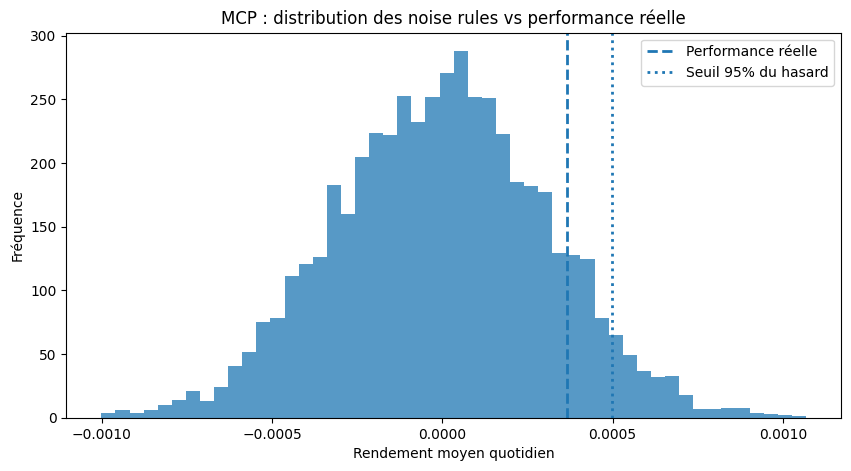

Seuil critique empirique à 5% : 0.00049932
Performance réelle : 0.00036473
p-value MCP : 0.1206


In [5]:
plt.figure(figsize=(10, 5))
plt.hist(permuted_means, bins=50, alpha=0.75)
plt.axvline(real_mean, linestyle="--", linewidth=2, label="Performance réelle")
plt.axvline(np.percentile(permuted_means, 95), linestyle=":", linewidth=2, label="Seuil 95% du hasard")
plt.title("MCP : distribution des noise rules vs performance réelle")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Seuil critique empirique à 5% : {np.percentile(permuted_means, 95):.8f}")
print(f"Performance réelle : {real_mean:.8f}")
print(f"p-value MCP : {p_value:.4f}")

## 7. Interprétation du verdict

La p-value MCP signifie :

> Parmi toutes les stratégies de bruit créées en mélangeant les rendements, quelle proportion a fait aussi bien ou mieux que ma vraie stratégie ?

Donc :

- `p-value = 0.50` : la stratégie est totalement banale ;
- `p-value = 0.20` : pas assez rare ;
- `p-value = 0.05` : seuil conventionnel de rareté ;
- `p-value = 0.01` : résultat très rare sous l'hypothèse de hasard.

Mais attention :

Une p-value faible ne veut pas dire que tu as trouvé le Saint Graal.  
Elle veut seulement dire :

> le résultat observé est difficile à expliquer par un appariement aléatoire signal/rendement sur cet échantillon.

In [6]:
if p_value < 0.05:
    verdict = "La stratégie passe le test MCP au seuil de 5%."
else:
    verdict = "La stratégie ne passe pas le test MCP au seuil de 5%."

print(verdict)

interpretation = pd.DataFrame({
    "Élément": [
        "Hypothèse nulle MCP",
        "Ce que détruit le test",
        "Ce que représente une noise rule",
        "Décision si p < 0.05",
        "Décision si p >= 0.05"
    ],
    "Interprétation": [
        "L'appariement signal/rendement est aléatoire.",
        "Le lien temporel entre les signaux et les rendements.",
        "La même stratégie, mais appliquée à des jours de marché mélangés.",
        "Le vrai appariement signal/prix est rarement reproduit par hasard.",
        "La performance réelle ressemble à ce que le hasard peut produire."
    ]
})

interpretation

La stratégie ne passe pas le test MCP au seuil de 5%.


,Élément,Interprétation
0,Hypothèse nulle MCP,L'appariement signal/rendement est aléatoire.
1,Ce que détruit le test,Le lien temporel entre les signaux et les rend...
2,Ce que représente une noise rule,"La même stratégie, mais appliquée à des jours ..."
3,Décision si p < 0.05,Le vrai appariement signal/prix est rarement r...
4,Décision si p >= 0.05,La performance réelle ressemble à ce que le ha...


## 8. Exemple négatif : une stratégie sans edge

Maintenant, on crée une stratégie de bruit dès le départ.

Ses signaux sont aléatoires.

Elle peut quand même gagner par chance sur un historique donné.

Mais normalement, le MCP devrait montrer que sa performance n'est pas exceptionnelle.

Rendement moyen réel de la stratégie bruit : 0.00033644
p-value MCP de la stratégie bruit : 0.1394


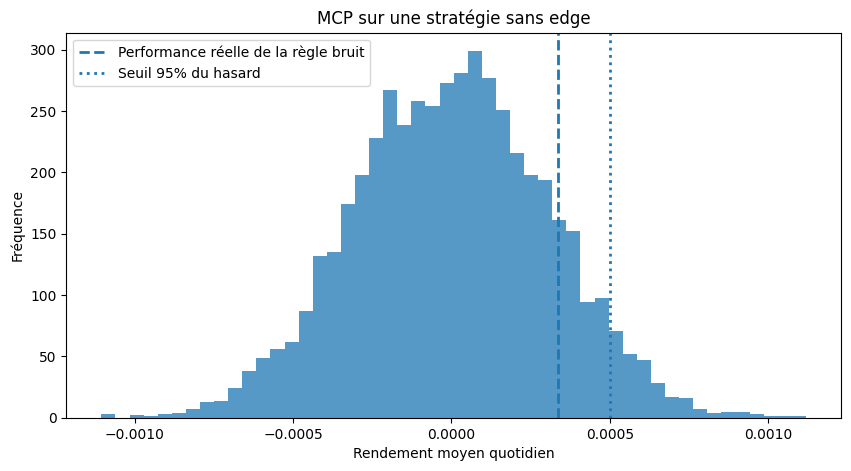

In [7]:
rng = np.random.default_rng(123)

noise_signals = rng.choice([-1, 0, 1], size=n_days, p=[0.4, 0.2, 0.4])
noise_real_mean, noise_permuted_means, noise_p_value = monte_carlo_permutation_test(
    signals=noise_signals,
    returns=df["market_return_detrended"],
    n_permutations=n_permutations,
    seed=123
)

print(f"Rendement moyen réel de la stratégie bruit : {noise_real_mean:.8f}")
print(f"p-value MCP de la stratégie bruit : {noise_p_value:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(noise_permuted_means, bins=50, alpha=0.75)
plt.axvline(noise_real_mean, linestyle="--", linewidth=2, label="Performance réelle de la règle bruit")
plt.axvline(np.percentile(noise_permuted_means, 95), linestyle=":", linewidth=2, label="Seuil 95% du hasard")
plt.title("MCP sur une stratégie sans edge")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 9. Application au data mining : tester le meilleur parmi plusieurs règles

Le piège du data mining :

> Si je teste 100 règles, il est presque normal qu'une règle ait l'air excellente par chance.

Dans ce cas, il ne suffit pas de tester la meilleure règle seule.  
Il faut comparer sa performance à ce que le hasard peut produire quand il a lui aussi le droit de choisir le meilleur parmi plusieurs règles.

Logique :

1. on calcule la meilleure performance réelle parmi plusieurs règles ;
2. à chaque permutation, on mélange les rendements ;
3. on calcule la performance de toutes les règles sur les rendements mélangés ;
4. on garde la meilleure performance bruitée ;
5. on compare la meilleure vraie règle à la meilleure noise rule.

C'est l'idée derrière l'antidote au data mining.

In [8]:
# Créons un univers de règles candidates :
# - 1 règle avec edge faible
# - 49 règles bruitées
n_rules = 50

rng = np.random.default_rng(777)
candidate_signals = []

candidate_signals.append(signals)  # règle avec edge

for _ in range(n_rules - 1):
    candidate_signals.append(rng.choice([-1, 0, 1], size=n_days, p=[0.4, 0.2, 0.4]))

candidate_signals = np.array(candidate_signals)

# Performance réelle de chaque règle
real_rule_means = (candidate_signals * df["market_return_detrended"].values).mean(axis=1)

best_real_idx = np.argmax(real_rule_means)
best_real_mean = real_rule_means[best_real_idx]

print(f"Meilleure règle réelle : règle #{best_real_idx}")
print(f"Performance moyenne de la meilleure règle réelle : {best_real_mean:.8f}")

# MCP version data mining : à chaque permutation, on garde le meilleur résultat parmi toutes les règles
rng = np.random.default_rng(999)
best_noise_means = np.empty(n_permutations)

returns = df["market_return_detrended"].values

for i in range(n_permutations):
    permuted_returns = rng.permutation(returns)
    noise_means_for_all_rules = (candidate_signals * permuted_returns).mean(axis=1)
    best_noise_means[i] = noise_means_for_all_rules.max()

data_mining_p_value = np.mean(best_noise_means >= best_real_mean)

print(f"p-value MCP ajustée data mining : {data_mining_p_value:.4f}")

Meilleure règle réelle : règle #9
Performance moyenne de la meilleure règle réelle : 0.00093219
p-value MCP ajustée data mining : 0.0672


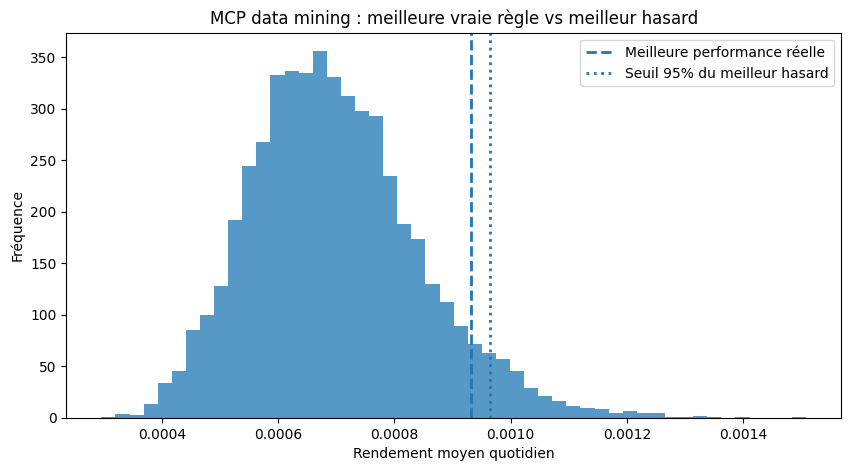

Seuil critique empirique data mining à 5% : 0.00096386
Meilleure performance réelle : 0.00093219
p-value MCP ajustée data mining : 0.0672


In [9]:
plt.figure(figsize=(10, 5))
plt.hist(best_noise_means, bins=50, alpha=0.75)
plt.axvline(best_real_mean, linestyle="--", linewidth=2, label="Meilleure performance réelle")
plt.axvline(np.percentile(best_noise_means, 95), linestyle=":", linewidth=2, label="Seuil 95% du meilleur hasard")
plt.title("MCP data mining : meilleure vraie règle vs meilleur hasard")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Seuil critique empirique data mining à 5% : {np.percentile(best_noise_means, 95):.8f}")
print(f"Meilleure performance réelle : {best_real_mean:.8f}")
print(f"p-value MCP ajustée data mining : {data_mining_p_value:.4f}")

## 10. Pourquoi le detrending est important ici

Si le marché a un drift haussier, une stratégie souvent long peut paraître intelligente alors qu'elle profite simplement du vent arrière du marché.

Le MCP doit idéalement utiliser des rendements de marché **detrendés** pour éviter de donner du crédit à une règle qui ne fait que capturer le drift.

En clair :

```text
rendement detrendé = rendement brut - moyenne des rendements bruts
```

Cela ne veut pas dire qu'on détruit toute la structure de prix pour générer les signaux.  
Dans une logique pratique :

1. tu peux générer tes signaux sur les données de prix normales ;
2. puis tester la relation signal/rendement sur des rendements ajustés/detrendés.

C'est une distinction capitale pour les stratégies price action.

In [10]:
comparison = pd.DataFrame({
    "Type de rendement": ["Brut", "Detrendé"],
    "Moyenne": [market_returns_raw.mean(), market_returns_detrended.mean()],
    "Écart-type": [market_returns_raw.std(), market_returns_detrended.std()]
})

comparison

,Type de rendement,Moyenne,Écart-type
0,Brut,1.710221e-04,0.00983
1,Detrendé,5.204170e-20,0.00983


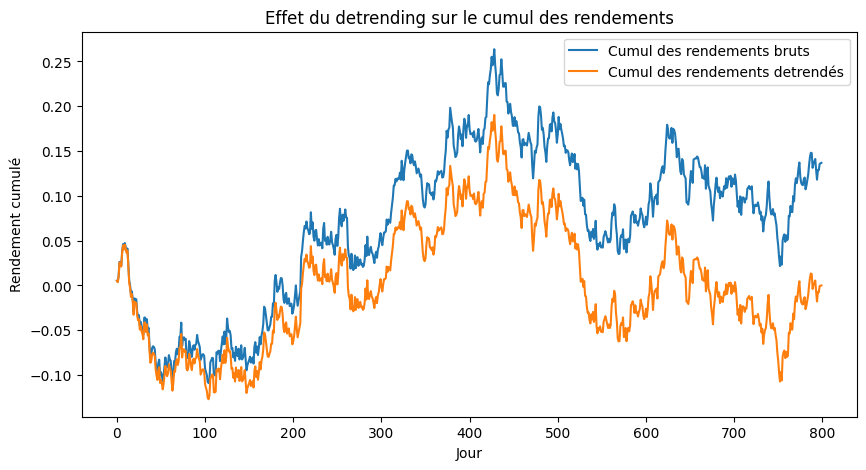

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(market_returns_raw), label="Cumul des rendements bruts")
plt.plot(np.cumsum(market_returns_detrended), label="Cumul des rendements detrendés")
plt.title("Effet du detrending sur le cumul des rendements")
plt.xlabel("Jour")
plt.ylabel("Rendement cumulé")
plt.legend()
plt.show()

## 11. Template pratique pour tes propres backtests

Pour appliquer le MCP à une stratégie réelle, tu as besoin de sauvegarder au minimum :

- la date ;
- le signal ou la position : `+1`, `0`, `-1` ;
- le rendement du marché correspondant ;
- idéalement le rendement detrendé ;
- le rendement de stratégie : `signal × rendement`.

Pseudo-code :

```python
signals = df["position"].values
returns = df["market_return_detrended"].values

real_mean, permuted_means, p_value = monte_carlo_permutation_test(
    signals=signals,
    returns=returns,
    n_permutations=5000
)
```

Verdict :

```python
if p_value < 0.05:
    print("Le lien signal/prix est rarement reproduit par hasard.")
else:
    print("La performance ressemble à une coïncidence possible.")
```

## 12. Les erreurs d'interprétation à éviter

### Erreur 1 : croire que MCP prouve définitivement une stratégie

Non.  
MCP ne prouve pas que la stratégie gagnera dans le futur.  
Il dit seulement que sur cet échantillon, le lien signal/prix est difficile à reproduire par permutation aléatoire.

### Erreur 2 : oublier les coûts de transaction

Une stratégie peut passer MCP avant frais et être inutilisable après frais.

### Erreur 3 : tester une seule règle après en avoir essayé 200

Si tu as testé beaucoup de variantes, il faut faire une version ajustée data mining, sinon tu sous-estimes la chance.

### Erreur 4 : confondre performance et relation logique

Le MCP n'est pas juste un test de profit.  
C'est un test de **placement des signaux**.

La vraie question :

> Mes signaux tombent-ils sur les bons rendements plus souvent que ce que le hasard peut produire ?

## 13. Résumé final

À retenir absolument :

1. **MCP = test de la relation signal/prix.**
2. Il garde les signaux, mais mélange les rendements.
3. Il crée des milliers de **noise rules**.
4. La p-value mesure combien de noise rules font aussi bien ou mieux que la vraie règle.
5. Il est très utile contre le data mining.
6. Il nécessite idéalement des rendements detrendés.
7. Une p-value faible est un indice de validité, pas une garantie de profits futurs.

Phrase à graver :

> Une stratégie n'est pas validée parce qu'elle a gagné. Elle devient intéressante quand le hasard, même répété des milliers de fois, n'arrive pas à reproduire son appariement signal/prix.

# Annexe - Source originale collée par l'utilisateur

Cette annexe conserve le texte source qui a servi de base au notebook.

### **MONTE CARLO PERMUTATION METHOD (MCP)**

Voici l'analyse technique de la méthode de permutation de Monte Carlo, l'alternative au Bootstrap privilégiée par David Aronson pour briser tout lien logique entre un signal de trading et le marché afin d'isoler la pure chance,.

**(AJOUT) Idées clés :**
*   **Destruction du pouvoir prédictif :** L'MCP brise délibérément la relation temporelle entre les signaux de la règle et les rendements du marché pour créer une "règle de bruit".
*   **Hypothèse Nulle spécifique :** Contrairement au Bootstrap qui teste la moyenne des rendements, l'MCP teste si l'appariement entre signal et prix est purement aléatoire,.
*   **Appariement sans remise :** La méthode consiste à coupler les signaux originaux (+1/-1) avec une version mélangée (scrambled) de l'historique des prix,.
*   **Antidote au Data Mining :** Utilisé pour déterminer si le "meilleur" résultat d'un groupe de règles est simplement le fruit d'une coïncidence heureuse,.

**Référence :**
*Monte Carlo Permutation Method (MCP)* (Pages 238–241) ; *Application to Data Mining* (Pages 327–329),,.

**Citation Directe :**
« The random pairing of the rule output values with market changes destroys any predictive power that the rule may have had. I refer to this random pairing as a noise rule. » (Page 239).

**Vision Macro :**
L'enjeu est de prouver que vos signaux d'achat et de vente ne sont pas juste du "bruit" qui a eu de la chance. David Aronson explique que sur un historique donné, il est possible qu'une suite de signaux aléatoires corresponde parfaitement aux mouvements du marché par pur accident,. L'MCP agit comme un "mélangeur de cartes" : il garde vos décisions mais les applique à des jours de marché choisis au hasard. Si votre performance réelle n'est pas bien meilleure que ces milliers de tests "mélangés", alors votre stratégie n'a aucune valeur intellectuelle ; elle est statistiquement indiscernable d'un singe lançant des fléchettes,.

**Vision Micro : Le Processus pas à pas**
1.  **Données d'entrée :** On utilise la séquence chronologique des signaux de la règle (+1, -1) et la série des rendements quotidiens **detrendés** du marché,.
2.  **Permutation (Le mélange) :** On prend tous les rendements quotidiens du marché, on les met dans une "urne" virtuelle, et on les tire un par un **sans remise** pour les associer aux signaux de la règle dans leur ordre original,,.
3.  **Calcul du profit "Bruit" :** Pour chaque jour, on multiplie le signal (+1/-1) par le rendement permuté. On calcule ensuite la moyenne de ces résultats pour obtenir le rendement d'une "règle de bruit",.
4.  **Simulation massive :** On répète ce mélange et ce calcul 5 000 fois pour construire la distribution d'échantillonnage de la chance,.
5.  **Verdict (p-value) :** On regarde combien de fois (sur 5 000) le hasard a fait mieux que votre règle réelle. Si c'est moins de 5% du temps (p < 0,05), l'appariement entre vos signaux et le prix est jugé intentionnel et prédictif,.

**(AJOUT) Résumé Simplifié :**
Imagine que tu prétendes connaître le résultat de 10 matchs de foot. Pour vérifier, on prend tes 10 pronostics et on les compare à 10 matchs tirés au hasard dans l'histoire. Si tu as toujours raison même sur des matchs aléatoires, c'est que tu as de la chance. Si tu n'as raison **que** sur les vrais matchs et que le hasard échoue lamentablement, alors tu as un vrai don de voyance,.

**Actions Concrètes :**
*   **Utilisez l'MCP pour valider la logique :** Si votre règle est complexe, l'MCP est le meilleur test pour vérifier que la complexité n'est pas juste un "ajustement au bruit".
*   **Conservez les signaux :** Pour appliquer l'MCP, vous devez enregistrer la suite de vos positions (+1, 0, -1) et non pas seulement le résultat final,.
*   **Priorité au domaine public :** David Aronson note que l'MCP est dans le domaine public (développé par Dr. Timothy Masters), contrairement à certaines versions brevetées du Bootstrap,.

**(AJOUT) À retenir absolument :**
*   **MCP** = Test de la validité de la relation **Signal/Prix**.
*   Utilise le rééchantillonnage **sans remise**,.
*   Crée une **"Noise Rule"** (Règle de bruit) comme étalon.
*   Nécessite impérativement des données **detrendées** pour être juste,.
*   Fournit une **p-value** presque identique au Bootstrap si les données sont bien centrées.

J'ai terminé l'analyse de la méthode de permutation de Monte Carlo selon le protocole EBTA.